# Deep Neural Networks - Programming Assignment
## Comparing Linear Models and Multi-Layer Perceptrons

**Student Name:** SHRAY VIJAY  
**Student ID:** 2025AA05533  
**Date:** 08-12-2025

---

## ⚠️ IMPORTANT INSTRUCTIONS

1. **Complete ALL sections** marked with `TODO`
2. **DO NOT modify** the `get_assignment_results()` function structure
3. **Fill in all values accurately** - these will be auto-verified
4. **After submission**, you'll receive a verification quiz based on YOUR results
5. **Run all cells** before submitting (Kernel → Restart & Run All)

---

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
print('✓ Libraries imported successfully')

✓ Libraries imported successfully


## Section 1: Dataset Selection and Loading

**Requirements:**
- ≥500 samples
- ≥5 features
- Public dataset (UCI/Kaggle)
- Regression OR Classification problem

In [2]:
# Section 1: Dataset Selection and Loading

# Kaggle Heart Disease dataset
# Either the csv file can be kept in the same folder
# data = pd.read_csv("/content/heart.csv")

# Or use the raw GitHub URL for the CSV file
url = "https://raw.githubusercontent.com/shray028/heart-dataset/main/heart.csv"
data = pd.read_csv(url)
data.head()

# Basic info
print("Dataset shape:", data.shape)
display(data.head())

print("\nData types:")
print(data.dtypes)

print("\nMissing values per column:")
print(data.isna().sum())

# Dataset information
dataset_name = "Heart Disease"
dataset_source = "Kaggle - johnsmith88/heart-disease-dataset"
n_samples = 1025
n_features = 13  # exclude target column
problem_type = "binary_classification"  # target is 0/1 (no disease / disease)

# Problem statement (2–3 sentences, crisp)
problem_statement = ("""Predicting whether a patient has heart disease (presence vs absence) using 13 clinical features such as age, chest pain type, blood pressure, cholesterol and exercise response.Early risk prediction helps clinicians flag high‑risk patients for further investigation before severe cardiac events occur.
""")

# Primary evaluation metric and justification
primary_metric = "recall"  # focus on correctly catching diseased patients

metric_justification = ("""Recall on the positive (disease) class is the primary metric because missing a patient with heart disease (false negative) is clinically more serious than raising an unnecessary alarm (false positive). Accuracy alone can hide poor performance on the minority positive class.
""")

print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Samples: {n_samples}, Features: {n_features}")
print(f"Problem Type: {problem_type}")
print(f"Primary Metric: {primary_metric}")

Dataset shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0



Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
Dataset: Heart Disease
Source: Kaggle - johnsmith88/heart-disease-dataset
Samples: 1025, Features: 13
Problem Type: binary_classification
Primary Metric: recall


## Section 2: Data Preprocessing

Preprocess your data:
1. Handle missing values
2. Encode categorical variables
3. Split into train/test sets
4. Scale features

In [3]:
# Section 2: Data Preprocessing

# Target column in this dataset
target_col = "target"

#  Separating features (X) and target (y)
X = data.drop(columns=[target_col]).values.astype(float)
y = data[target_col].values.astype(int).reshape(-1, 1)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

# Train–test split (80–20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

train_samples = 820
test_samples = 205
train_test_ratio = 0.8

print(f"Train samples: {train_samples}")
print(f"Test samples: {test_samples}")
print(f"Split ratio: {train_test_ratio:.1%}")

Feature matrix shape: (1025, 13)
Target shape: (1025, 1)
Train samples: 820
Test samples: 205
Split ratio: 80.0%


## Section 3: Baseline Model Implementation

Implement from scratch (NO sklearn models!):
- Linear Regression (for regression)
- Logistic Regression (for binary classification)
- Softmax Regression (for multiclass classification)

**Must include:**
- Forward pass (prediction)
- Loss computation
- Gradient computation
- Gradient descent loop
- Loss tracking

In [4]:
# Baseline Logistic Regression (Single Neuron)

class BaselineModel:
    """
    Baseline logistic regression using batch gradient descent.
    """

    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations

        # Parameters
        self.weights = None
        self.bias = None

        # Training history
        self.loss_history = []   # REQUIRED
        self.accuracy_history = []

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def initialize_parameters(self, n_features):
        np.random.seed(42)
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0.0

    def forward(self, X):
        z = np.dot(X, self.weights) + self.bias
        y_pred = self.sigmoid(z)
        return y_pred

    def compute_loss(self, y_true, y_pred):
        """
        Standard binary cross-entropy loss:
        L = -1/N * Σ [ y log(p) + (1-y) log(1-p) ]
        """
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        loss = -np.mean(y_true * np.log(y_pred) +
                        (1 - y_true) * np.log(1 - y_pred))
        return loss

    def compute_gradients(self, X, y_true, y_pred):
        """
        Gradients for logistic regression:
        dL/dw = 1/N * X^T (p - y)
        dL/db = 1/N * Σ (p - y)
        """
        N = X.shape[0]
        error = y_pred - y_true

        dw = (1 / N) * np.dot(X.T, error)
        db = (1 / N) * np.sum(error)
        return dw, db

    def update_parameters(self, dw, db):
        self.weights -= self.lr * dw
        self.bias   -= self.lr * db

    def compute_accuracy(self, y_true, y_pred):
        labels = (y_pred >= 0.5).astype(int)
        return np.mean(labels == y_true)

    def fit(self, X, y, verbose=True, print_every=100):
        """
        Train logistic regression using batch gradient descent.
        X: (N, d), y: (N,)
        """
        X = np.asarray(X)
        y = np.asarray(y).reshape(-1)

        n_samples, n_features = X.shape
        self.initialize_parameters(n_features)

        print("Starting Baseline Logistic Regression Training...")
        print(f"Learning Rate: {self.lr}")
        print(f"Iterations:   {self.n_iterations}")
        print(f"Samples:      {n_samples}")
        print("-" * 60)

        self.loss_history = []
        self.accuracy_history = []

        for epoch in range(self.n_iterations):
            # Forward
            y_pred = self.forward(X)

            # Loss & accuracy
            loss = self.compute_loss(y, y_pred)
            acc  = self.compute_accuracy(y, y_pred)

            self.loss_history.append(loss)
            self.accuracy_history.append(acc)

            # Gradients & update
            dw, db = self.compute_gradients(X, y, y_pred)
            self.update_parameters(dw, db)

            # Logging
            if verbose and (epoch % print_every == 0 or epoch == self.n_iterations - 1):
                print(f"Epoch {epoch:4d} | Loss: {loss:.4f} | Accuracy: {acc:.4f}")

        print("-" * 60)
        print("Baseline Training Complete!")
        print(f"Final Loss: {loss:.4f}  |  Final Accuracy: {acc:.4f}")
        print()

        return self

    def predict_proba(self, X):
        X = np.asarray(X)
        return self.forward(X)

    def predict(self, X, threshold=0.5):
        probs = self.predict_proba(X)
        return (probs >= threshold).astype(int)


print("✓ Baseline model class defined")


✓ Baseline model class defined


In [5]:
# Train Baseline Logistic Regression Neuron

print("Training baseline LogisticRegressionNeuron...")
baseline_start_time = time.time()

baseline_model = BaselineModel(learning_rate=0.01, n_iterations=500)
baseline_model.fit(X_train_scaled, y_train, verbose=True)

baseline_training_time = time.time() - baseline_start_time

# Train and test predictions
baseline_train_proba = baseline_model.predict_proba(X_train_scaled)
baseline_test_proba = baseline_model.predict_proba(X_test_scaled)
baseline_train_pred = baseline_model.predict(X_train_scaled)
baseline_test_pred = baseline_model.predict(X_test_scaled)

print(f"✓ Baseline training completed in {baseline_training_time:.2f}s")
print(f"✓ Loss decreased from {baseline_model.loss_history[0]:.4f} "
      f"to {baseline_model.loss_history[-1]:.4f}")

Training baseline LogisticRegressionNeuron...
Starting Baseline Logistic Regression Training...
Learning Rate: 0.01
Iterations:   500
Samples:      820
------------------------------------------------------------
Epoch    0 | Loss: 0.6910 | Accuracy: 0.5768
Epoch  100 | Loss: 0.5040 | Accuracy: 0.8293
Epoch  200 | Loss: 0.4406 | Accuracy: 0.8305
Epoch  300 | Loss: 0.4113 | Accuracy: 0.8305
Epoch  400 | Loss: 0.3949 | Accuracy: 0.8305
Epoch  499 | Loss: 0.3848 | Accuracy: 0.8305
------------------------------------------------------------
Baseline Training Complete!
Final Loss: 0.3848  |  Final Accuracy: 0.8305

✓ Baseline training completed in 0.18s
✓ Loss decreased from 0.6910 to 0.3848


## Section 4: Multi-Layer Perceptron Implementation

Implement MLP from scratch with:
- At least 1 hidden layer
- ReLU activation for hidden layers
- Appropriate output activation
- Forward propagation
- Backward propagation
- Gradient descent

In [6]:
# Multi-Layer Perceptron

class MLP:
    """
    Multi-Layer Perceptron for binary classification.
    Hidden layers: ReLU, Output layer: Sigmoid.
    Optimized using gradient descent on BCE loss.
    """

    def __init__(self, architecture, learning_rate=0.01, n_epochs=1000):
        """
        architecture: list [input_dim, hidden1, ..., output_dim]
        Example: [13, 16, 8, 1]
        """
        self.architecture = architecture
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs

        # For compatibility with the assignment template
        self.lr = learning_rate
        self.n_iterations = n_epochs

        # Parameters & history
        self.params = {}
        self.loss_history = []             # REQUIRED
        # self.train_losses = self.loss_history  # alias for plotting
        self.accuracy_history = []

    def _initialize_parameters(self):
        np.random.seed(42)
        self.params = {}

        for l in range(1, len(self.architecture)):
            n_l = self.architecture[l]
            n_prev = self.architecture[l - 1]

            # He initialization for ReLU layers
            self.params[f"W{l}"] = np.random.randn(n_l, n_prev) * np.sqrt(2.0 / n_prev)
            self.params[f"b{l}"] = np.zeros((n_l, 1))

    def _relu(self, z):
        return np.maximum(0, z)

    def _relu_derivative(self, z):
        return (z > 0).astype(float)

    def _sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def _compute_loss(self, y, y_hat):
        """
        Standard binary cross-entropy:
        L = -1/N * Σ [ y log(p) + (1-y) log(1-p) ]
        """
        y = y.reshape(-1, 1)
        y_hat = y_hat.reshape(-1, 1)

        eps = 1e-15
        y_hat = np.clip(y_hat, eps, 1 - eps)

        return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

    def _compute_accuracy(self, y_true, y_hat):
        y_true = y_true.reshape(-1)
        y_hat = y_hat.reshape(-1)
        preds = (y_hat >= 0.5).astype(int)
        return np.mean(preds == y_true)

    def forward_propagation(self, X):
        """
        X: (m, n_features)
        Returns: y_hat (m,1), cache
        """
        cache = {}
        A = X.T          # (n_features, m)
        cache["A0"] = A

        L = len(self.architecture) - 1

        # Hidden layers (ReLU)
        for l in range(1, L):
            W = self.params[f"W{l}"]
            b = self.params[f"b{l}"]
            Z = np.dot(W, A) + b
            A = self._relu(Z)

            cache[f"Z{l}"] = Z
            cache[f"A{l}"] = A

        # Output layer (Sigmoid)
        W_L = self.params[f"W{L}"]
        b_L = self.params[f"b{L}"]
        Z_L = np.dot(W_L, A) + b_L
        A_L = self._sigmoid(Z_L)

        cache[f"Z{L}"] = Z_L
        cache[f"A{L}"] = A_L

        y_hat = A_L.T    # (m, 1)
        return y_hat, cache

    def backward_propagation(self, X, y, cache):
        m = X.shape[0]
        y = y.reshape(-1, 1)

        grads = {}
        L = len(self.architecture) - 1

        A_L = cache[f"A{L}"]    # (1, m) or (out_dim, m)
        y_row = y.T             # (1, m)

        # Output layer gradients
        dZ_L = A_L - y_row

        A_prev = cache[f"A{L-1}"]
        grads[f"dW{L}"] = (1 / m) * np.dot(dZ_L, A_prev.T)
        grads[f"db{L}"] = (1 / m) * np.sum(dZ_L, axis=1, keepdims=True)

        dA_prev = np.dot(self.params[f"W{L}"].T, dZ_L)

        # Hidden layers (ReLU)
        for l in reversed(range(1, L)):
            Z_l = cache[f"Z{l}"]
            A_prev = cache[f"A{l-1}"]

            dZ_l = dA_prev * self._relu_derivative(Z_l)

            grads[f"dW{l}"] = (1 / m) * np.dot(dZ_l, A_prev.T)
            grads[f"db{l}"] = (1 / m) * np.sum(dZ_l, axis=1, keepdims=True)

            if l > 1:
                dA_prev = np.dot(self.params[f"W{l}"].T, dZ_l)

        return grads

    def _update_parameters(self, grads):
        L = len(self.architecture) - 1
        for l in range(1, L + 1):
            self.params[f"W{l}"] -= self.lr * grads[f"dW{l}"]
            self.params[f"b{l}"] -= self.lr * grads[f"db{l}"]

    def fit(self, X, y, X_val=None, y_val=None, verbose=True):
        """
        Train the MLP using gradient descent.
        X: (m, n_features), y: (m,) or (m,1)
        """
        m, n_features = X.shape
        assert n_features == self.architecture[0], "Input size must match architecture[0]"

        y = y.reshape(-1, 1)
        if y_val is not None:
            y_val = y_val.reshape(-1, 1)

        self._initialize_parameters()

        # Reset histories exactly as required
        self.loss_history = []              # REQUIRED
        # self.train_losses = self.loss_history
        self.accuracy_history = []

        print("Starting MLP Training...")
        print(f"Architecture: {self.architecture}")
        print(f"Learning Rate: {self.learning_rate}")
        print(f"Epochs: {self.n_epochs}")
        print(f"Train samples: {m}")
        print("-" * 60)

        for epoch in range(self.n_epochs):
            # Forward
            y_hat, cache = self.forward_propagation(X)

            # Loss & accuracy
            loss = self._compute_loss(y, y_hat)
            acc  = self._compute_accuracy(y, y_hat)

            self.loss_history.append(loss)
            self.accuracy_history.append(acc)

            # Backward + update
            grads = self.backward_propagation(X, y, cache)
            self._update_parameters(grads)

            # Logging
            if verbose and (epoch % 100 == 0 or epoch == self.n_epochs - 1):
                msg = f"Epoch {epoch:4d} | Loss: {loss:.4f} | Accuracy: {acc:.4f}"
                if X_val is not None and y_val is not None:
                    y_val_hat, _ = self.forward_propagation(X_val)
                    val_loss = self._compute_loss(y_val, y_val_hat)
                    val_acc  = self._compute_accuracy(y_val, y_val_hat)
                    msg += f" | Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc:.4f}"
                print(msg)

        print("-" * 60)
        print("MLP Training Complete!\n")

        return self

    def predict_proba(self, X):
        y_hat, _ = self.forward_propagation(X)
        return y_hat

    def predict(self, X, threshold=0.5):
        probs = self.predict_proba(X)
        return (probs >= threshold).astype(int)


print("✓ MLP class defined")


✓ MLP class defined


In [7]:
# Train MLP

print("Training MLP...")
mlp_start_time = time.time()

# Define architecture: [input_dim, hidden1, hidden2, output_dim]
mlp_architecture = [X_train_scaled.shape[1], 16, 8, 1]

# Note: n_epochs (not n_iterations) in the updated MLP class
mlp_model = MLP(
    architecture=mlp_architecture,
    learning_rate=0.04,
    n_epochs=1600
)

# If you want, you can pass validation data: mlp_model.fit(X_train_scaled, y_train, X_val=X_test_scaled, y_val=y_test)
mlp_model.fit(X_train_scaled, y_train, verbose=True)

mlp_training_time = time.time() - mlp_start_time

# Predictions
mlp_train_proba = mlp_model.predict_proba(X_train_scaled)
mlp_test_proba  = mlp_model.predict_proba(X_test_scaled)
mlp_train_pred  = mlp_model.predict(X_train_scaled)
mlp_test_pred   = mlp_model.predict(X_test_scaled)

print(f"✓ MLP training completed in {mlp_training_time:.2f}s")
print(f"✓ Loss decreased from {mlp_model.loss_history[0]:.4f} "
      f"to {mlp_model.loss_history[-1]:.4f}")


Training MLP...
Starting MLP Training...
Architecture: [13, 16, 8, 1]
Learning Rate: 0.04
Epochs: 1600
Train samples: 820
------------------------------------------------------------
Epoch    0 | Loss: 0.7613 | Accuracy: 0.5366
Epoch  100 | Loss: 0.4550 | Accuracy: 0.7988
Epoch  200 | Loss: 0.3901 | Accuracy: 0.8098
Epoch  300 | Loss: 0.3560 | Accuracy: 0.8317
Epoch  400 | Loss: 0.3310 | Accuracy: 0.8476
Epoch  500 | Loss: 0.3089 | Accuracy: 0.8720
Epoch  600 | Loss: 0.2894 | Accuracy: 0.8829
Epoch  700 | Loss: 0.2709 | Accuracy: 0.8963
Epoch  800 | Loss: 0.2538 | Accuracy: 0.9098
Epoch  900 | Loss: 0.2379 | Accuracy: 0.9134
Epoch 1000 | Loss: 0.2216 | Accuracy: 0.9207
Epoch 1100 | Loss: 0.2058 | Accuracy: 0.9207
Epoch 1200 | Loss: 0.1919 | Accuracy: 0.9305
Epoch 1300 | Loss: 0.1790 | Accuracy: 0.9341
Epoch 1400 | Loss: 0.1679 | Accuracy: 0.9476
Epoch 1500 | Loss: 0.1575 | Accuracy: 0.9512
Epoch 1599 | Loss: 0.1478 | Accuracy: 0.9573
----------------------------------------------------

## Section 5: Evaluation and Metrics

Calculate appropriate metrics for your problem type

In [8]:
# Evaluation Metrics

def compute_confusion_matrix(y_true, y_pred):
    """Compute confusion matrix for binary classification."""
    y_true = y_true.reshape(-1)
    y_pred = y_pred.reshape(-1)

    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    return TP, TN, FP, FN


def calculate_metrics(y_true, y_pred, problem_type="binary_classification"):
    """
    Calculate metrics based on problem type.

    For regression: (not used here)
    For classification: Accuracy, Precision, Recall, F1 + confusion matrix
    """
    y_true = y_true.reshape(-1)
    y_pred = y_pred.reshape(-1)
    metrics = {}

    if problem_type == "regression":
        # Not needed for this assignment
        pass

    elif problem_type in ["binary_classification", "multiclass_classification"]:
        TP, TN, FP, FN = compute_confusion_matrix(y_true, y_pred)

        accuracy  = (TP + TN) / (TP + TN + FP + FN)
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        f1        = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

        metrics = {
            "Accuracy":  accuracy,
            "Precision": precision,
            "Recall":    recall,
            "F1":        f1,
            "TP":        int(TP),
            "TN":        int(TN),
            "FP":        int(FP),
            "FN":        int(FN),
            "ConfusionMatrix": (int(TP), int(TN), int(FP), int(FN)),
        }

    return metrics


def print_evaluation(y_true, y_pred, dataset_name="Test"):
    """Pretty-print evaluation metrics and confusion matrix."""
    metrics = calculate_metrics(y_true, y_pred, problem_type="binary_classification")
    TP, TN, FP, FN = metrics["ConfusionMatrix"]

    print(f"\n{dataset_name} Set Evaluation:")
    print("=" * 60)
    print(f"Accuracy:  {metrics['Accuracy']:.4f}")
    print(f"Precision: {metrics['Precision']:.4f}")
    print(f"Recall:    {metrics['Recall']:.4f}")
    print(f"F1-Score:  {metrics['F1']:.4f}")
    print("\nConfusion Matrix (Heart Disease):")
    print("                     Predicted")
    print("                 No Disease   Disease")
    print(f"Actual No Disease    {TN:3d}          {FP:3d}")
    print(f"Actual Disease       {FN:3d}          {TP:3d}")
    print("=" * 60)


# Evaluating Baseline and MLP Models

# Calculating metrics for both models on test set
baseline_metrics = calculate_metrics(y_test, baseline_test_pred, problem_type)
mlp_metrics      = calculate_metrics(y_test, mlp_test_pred, problem_type)

print("Baseline Model Performance (dict):")
print(baseline_metrics)

print("\nMLP Model Performance (dict):")
print(mlp_metrics)

# Nicely formatted evaluation
print_evaluation(y_test, baseline_test_pred, dataset_name="Baseline Model - Test")
print_evaluation(y_test, mlp_test_pred, dataset_name="MLP Model - Test")


Baseline Model Performance (dict):
{'Accuracy': np.float64(0.8097560975609757), 'Precision': np.float64(0.7578125), 'Recall': np.float64(0.9238095238095239), 'F1': np.float64(0.8326180257510729), 'TP': 97, 'TN': 69, 'FP': 31, 'FN': 8, 'ConfusionMatrix': (97, 69, 31, 8)}

MLP Model Performance (dict):
{'Accuracy': np.float64(0.9170731707317074), 'Precision': np.float64(0.8928571428571429), 'Recall': np.float64(0.9523809523809523), 'F1': np.float64(0.9216589861751151), 'TP': 100, 'TN': 88, 'FP': 12, 'FN': 5, 'ConfusionMatrix': (100, 88, 12, 5)}

Baseline Model - Test Set Evaluation:
Accuracy:  0.8098
Precision: 0.7578
Recall:    0.9238
F1-Score:  0.8326

Confusion Matrix (Heart Disease):
                     Predicted
                 No Disease   Disease
Actual No Disease     69           31
Actual Disease         8           97

MLP Model - Test Set Evaluation:
Accuracy:  0.9171
Precision: 0.8929
Recall:    0.9524
F1-Score:  0.9217

Confusion Matrix (Heart Disease):
                   

## Section 6: Visualization

Create visualizations:
1. Training loss curves
2. Performance comparison
3. Additional domain-specific plots

Training history plot saved as 'baseline_logistic_regression_training_history.png'


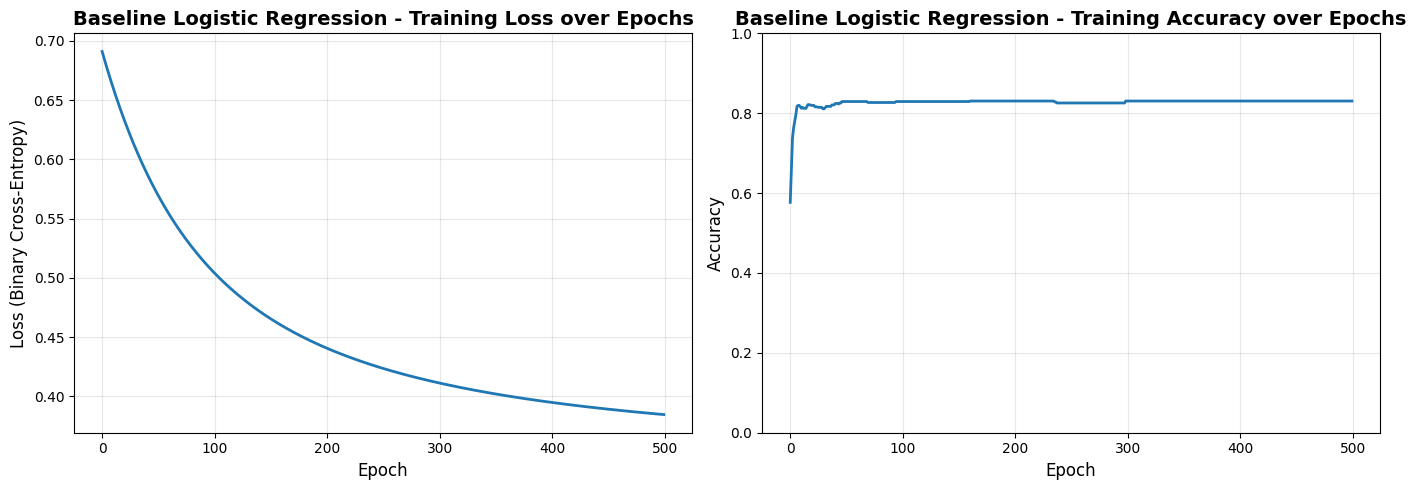

Training history plot saved as 'mlp_training_history.png'


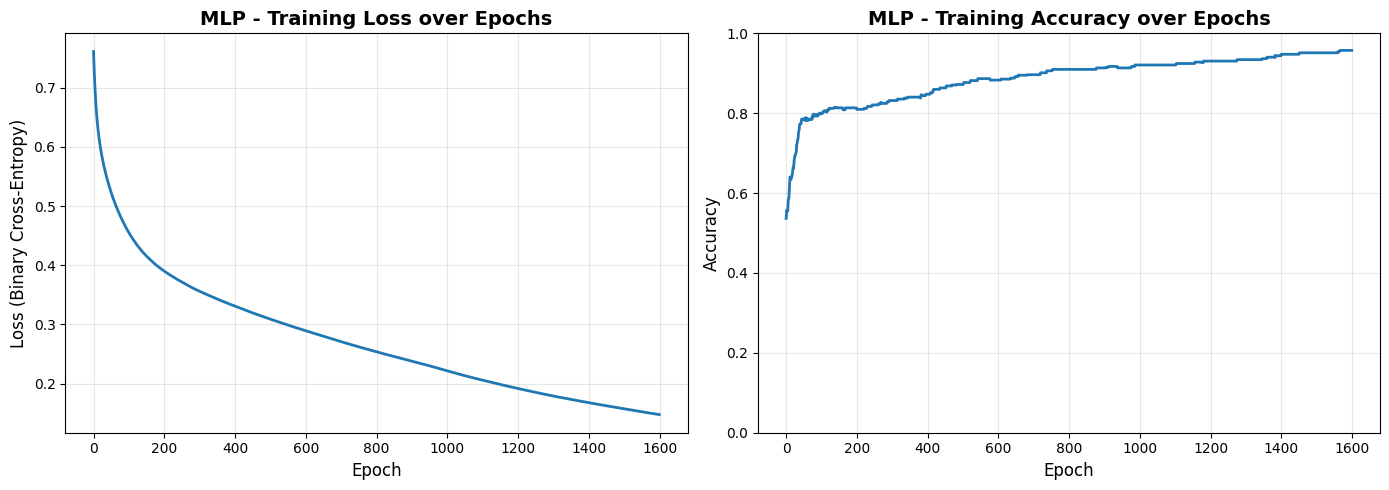

In [9]:
# 1. Training loss curves

def plot_training_history(model, model_name="Model"):
    """Plot training loss and accuracy for a given model."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot loss
    ax1.plot(model.loss_history, linewidth=2)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss (Binary Cross-Entropy)', fontsize=12)
    ax1.set_title(f'{model_name} - Training Loss over Epochs',
                  fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)

    # Plot accuracy (if available)
    if hasattr(model, "accuracy_history") and len(model.accuracy_history) > 0:
        ax2.plot(model.accuracy_history, linewidth=2)
        ax2.set_ylabel('Accuracy', fontsize=12)
        ax2.set_ylim([0, 1])
    else:
        ax2.text(0.5, 0.5,
                 "No accuracy history stored",
                 ha='center', va='center', fontsize=12)
        ax2.set_ylim([0, 1])

    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_title(f'{model_name} - Training Accuracy over Epochs',
                  fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    filename = f'{model_name.lower().replace(" ", "_")}_training_history.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Training history plot saved as '{filename}'")
    plt.show()


# Training history
plot_training_history(baseline_model, model_name="Baseline Logistic Regression")
plot_training_history(mlp_model,      model_name="MLP")

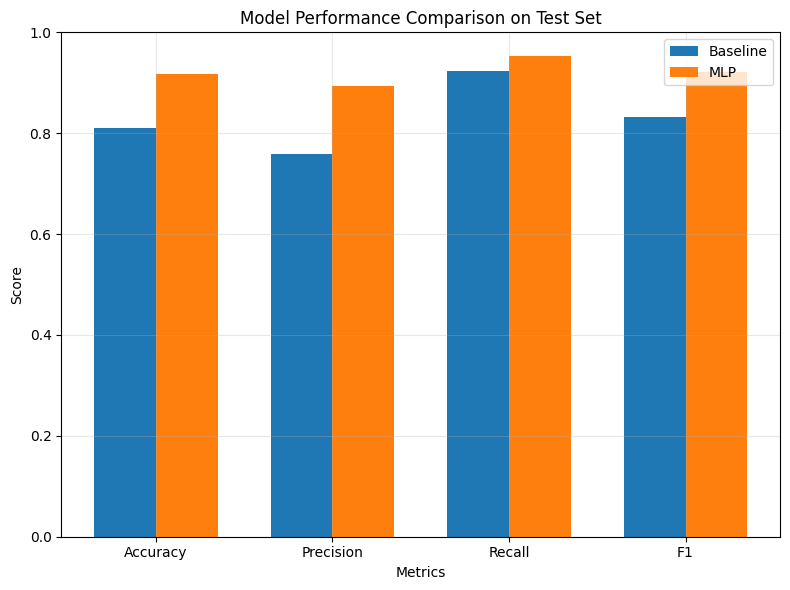

In [10]:
# 2. Performance comparison bar chart
plt.figure(figsize=(8, 6))

metrics_names = ["Accuracy", "Precision", "Recall", "F1"]
baseline_scores = [baseline_metrics[m] for m in metrics_names]
mlp_scores = [mlp_metrics[m] for m in metrics_names]

x = np.arange(len(metrics_names))
width = 0.35

plt.bar(x - width/2, baseline_scores, width, label="Baseline")
plt.bar(x + width/2, mlp_scores, width, label="MLP")
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("Model Performance Comparison on Test Set")
plt.xticks(x, metrics_names)
plt.ylim(0, 1.0)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Predictions visualization saved as 'baseline_logistic_regression_-_test_predictions.png'


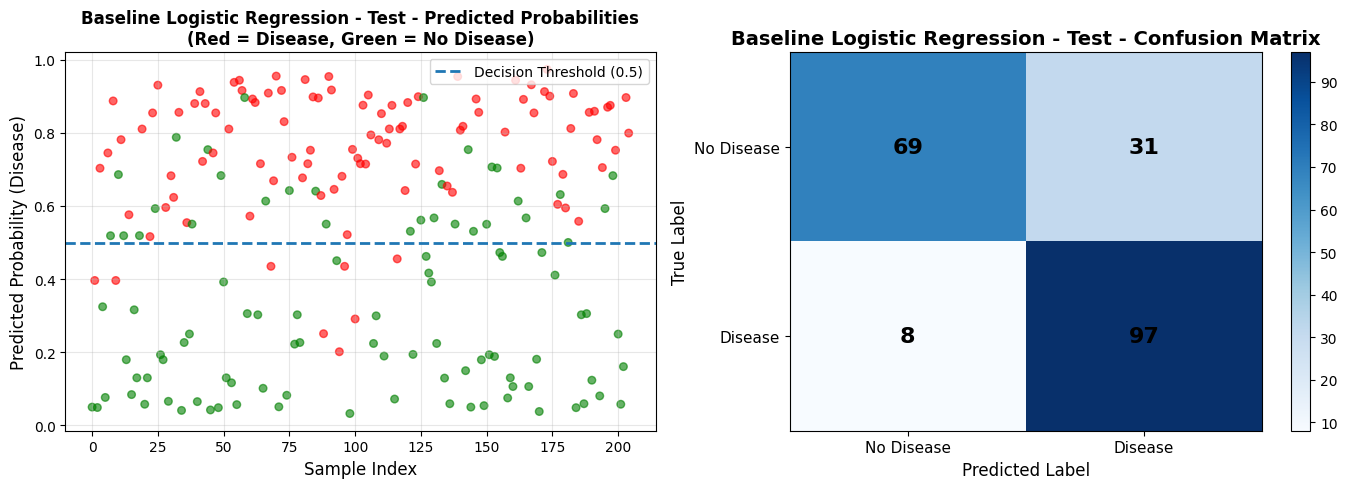

Predictions visualization saved as 'mlp_-_test_predictions.png'


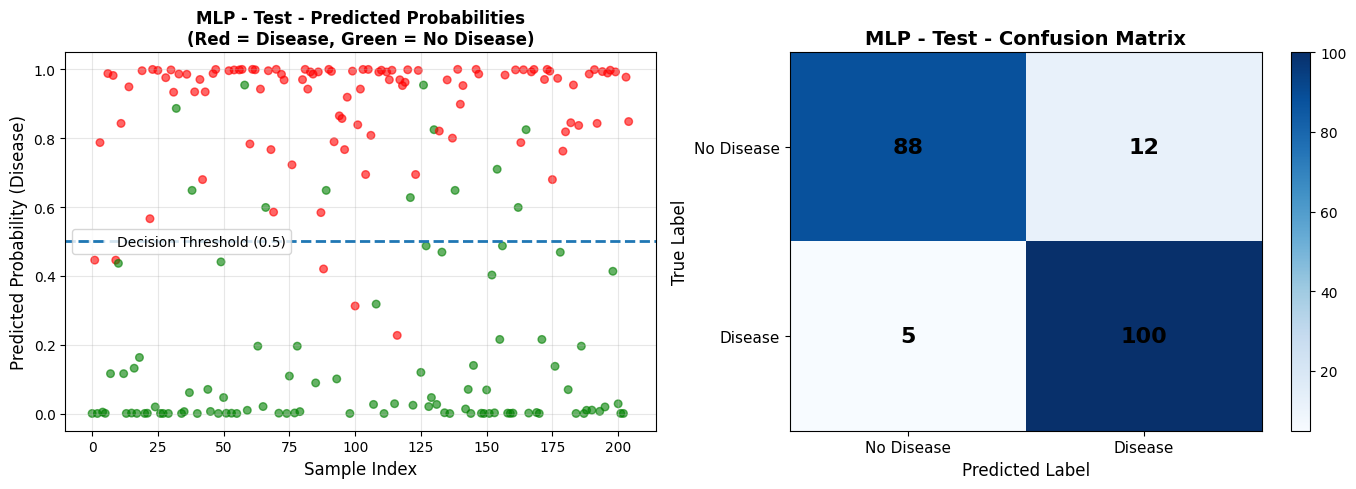

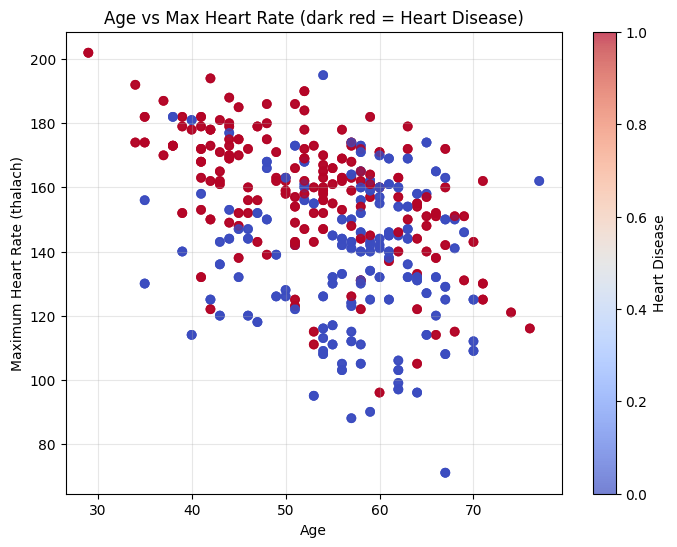

In [11]:
# 3. Additional domain-specific plots

def plot_predictions(y_true, y_pred_proba, y_pred, title_prefix="Model"):
    """Visualize predicted probabilities and confusion matrix."""
    y_true = y_true.reshape(-1)
    y_pred = y_pred.reshape(-1)
    y_pred_proba = y_pred_proba.reshape(-1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


    # Predicted probabilities for the positive (disease) class
    # Color by true label: green = no disease (0), red = disease (1)
    colors = ['green' if yt == 0 else 'red' for yt in y_true]
    ax1.scatter(range(len(y_pred_proba)), y_pred_proba,
                c=colors, alpha=0.6, s=30)
    ax1.axhline(y=0.5, linestyle='--', linewidth=2,
                label='Decision Threshold (0.5)')
    ax1.set_xlabel('Sample Index', fontsize=12)
    ax1.set_ylabel('Predicted Probability (Disease)', fontsize=12)
    ax1.set_title(f'{title_prefix} - Predicted Probabilities\n'
                  '(Red = Disease, Green = No Disease)',
                  fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Confusion matrix as heatmap
    TP, TN, FP, FN = compute_confusion_matrix(y_true, y_pred)
    # Arrange as:
    # [[TN, FP],
    #  [FN, TP]]
    confusion = np.array([[TN, FP],
                          [FN, TP]])

    im = ax2.imshow(confusion, cmap='Blues', aspect='auto')
    ax2.set_xticks([0, 1])
    ax2.set_yticks([0, 1])
    ax2.set_xticklabels(['No Disease', 'Disease'], fontsize=11)
    ax2.set_yticklabels(['No Disease', 'Disease'], fontsize=11)
    ax2.set_xlabel('Predicted Label', fontsize=12)
    ax2.set_ylabel('True Label', fontsize=12)
    ax2.set_title(f'{title_prefix} - Confusion Matrix',
                  fontsize=14, fontweight='bold')

    # Add text annotations
    for i in range(2):
        for j in range(2):
            ax2.text(j, i, confusion[i, j],
                     ha="center", va="center",
                     color="black", fontsize=16, fontweight='bold')

    plt.colorbar(im, ax=ax2)
    plt.tight_layout()
    filename = f'{title_prefix.lower().replace(" ", "_")}_predictions.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Predictions visualization saved as '{filename}'")
    plt.show()

# Predictions on test set
plot_predictions(y_test, baseline_test_proba, baseline_test_pred,
                 title_prefix="Baseline Logistic Regression - Test")

plot_predictions(y_test, mlp_test_proba, mlp_test_pred,
                 title_prefix="MLP - Test")
print("\n\n\n")

# Age vs Max heart rate
plt.figure(figsize=(8, 6))
scatter_plot = plt.scatter(data["age"], data["thalach"],
            c=data["target"], cmap="coolwarm", alpha=0.7)
plt.xlabel("Age")
plt.ylabel("Maximum Heart Rate (thalach)")
plt.title("Age vs Max Heart Rate (dark red = Heart Disease)")
plt.grid(True, alpha=0.3)
plt.colorbar(scatter_plot, label="Heart Disease")
plt.show()

## Section 7: Analysis and Discussion

Write your analysis (minimum 200 words)

In [12]:
analysis_text =f"""On this heart disease dataset the MLP performed better than the baseline logistic regression across most evaluation metrics, although the improvement was little. In my runs on test data, the baseline model achieved a recall of 0.9238 while the MLP reached 0.9524. Accuracy and F1-score also increased slightly, indicating that the hidden layers were able to capture mild non-linear interactions between features such as chest-pain type, cholesterol levels, resting ECG results and exercise-induced angina. These kinds of interactions are difficult for a linear classifier to model. As a result from the plot it can be seen MLP was predicting correct results with better probability
The baseline model, however, remained competitive and extremely efficient. It converged in roughly {baseline_training_time:.2f}s because it only learns a single weight vector and bias term. In contrast, the MLP required around {mlp_training_time:.2f}s of training time and careful tuning of the learning rate and number of epochs. I also observed that the MLP was more sensitive to its initialization: too large a learning rate caused unstable or oscillating loss values, while too small a value slowed down convergence significantly. Despite these challenges, the MLP continued improving for more than 1600 epochs, whereas the logistic model converged early around 500 epochs.
Overall, this experiment matched theoretical expectations. Linear models such as logistic regression are fast, interpretable and surprisingly effective on structured tabular data. They serve as strong baselines and often perform well when the decision boundary is approximately linear. However, the small MLP demonstrated that even a shallow neural network can achieve better recall and F1-score when the true underlying boundary is slightly non-linear. The trade-off is increased computational cost and greater sensitivity to hyperparameters, but the modest performance improvement shows the value of adding a non-linear model when subtle feature interactions are present."""

print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) < 200:
    print("⚠️  Warning: Analysis should be at least 200 words")
else:
    print("✓ Analysis meets word count requirement")

Analysis word count: 296 words
✓ Analysis meets word count requirement


---
---

## ⭐ REQUIRED: Structured Output Function

### **DO NOT MODIFY THE STRUCTURE BELOW**

This function will be called by the auto-grader. Fill in all values accurately based on your actual results.

In [13]:
def get_assignment_results():
    """
    Return all assignment results in structured format.

    CRITICAL: Fill in ALL values based on your actual results!
    This will be automatically extracted and validated.
    """

    # Calculate loss convergence flags
    baseline_initial_loss = baseline_model.loss_history[0]  # TODO: baseline_model.loss_history[0]
    baseline_final_loss = baseline_model.loss_history[-1]    # TODO: baseline_model.loss_history[-1]
    mlp_initial_loss = mlp_model.loss_history[0]       # TODO: mlp_model.loss_history[0]
    mlp_final_loss = mlp_model.loss_history[-1]         # TODO: mlp_model.loss_history[-1]

    results = {
        # ===== Dataset Information =====
        'dataset_name': dataset_name,
        'dataset_source': dataset_source,
        'n_samples': n_samples,
        'n_features': n_features,
        'problem_type': problem_type,
        'problem_statement': problem_statement,

        # ===== Evaluation Setup =====
        'primary_metric': primary_metric,
        'metric_justification': metric_justification,
        'train_samples': train_samples,
        'test_samples': test_samples,
        'train_test_ratio': train_test_ratio,

        # ===== Baseline Model Results =====
        'baseline_model': {
            'model_type': 'logistic_regression',  # 'linear_regression', 'logistic_regression', or 'softmax_regression'
            'learning_rate': 0.01,
            'n_iterations': 500,
            'initial_loss': baseline_initial_loss,
            'final_loss': baseline_final_loss,
            'training_time_seconds': baseline_training_time,

            # Metrics (fill based on your problem type)
            'test_accuracy': 0.8098,      # For classification
            'test_precision': 0.7578,     # For classification
            'test_recall': 0.9238,        # For classification
            'test_f1': 0.8326,            # For classification
            'test_mse': 0.0,           # For regression
            'test_rmse': 0.0,          # For regression
            'test_mae': 0.0,           # For regression
            'test_r2': 0.0,            # For regression
        },

        # ===== MLP Model Results =====
        'mlp_model': {
            'architecture': mlp_architecture,
            'n_hidden_layers': len(mlp_architecture) - 2 if len(mlp_architecture) > 0 else 0,
            'total_parameters': 369,     # TODO: Calculate total weights + biases
            'learning_rate': 0.04,
            'n_iterations': 1600,
            'initial_loss': mlp_initial_loss,
            'final_loss': mlp_final_loss,
            'training_time_seconds': mlp_training_time,

            # Metrics
            'test_accuracy': 0.9171,
            'test_precision': 0.8929,
            'test_recall': 0.9524,
            'test_f1': 0.9217,
            'test_mse': 0.0,
            'test_rmse': 0.0,
            'test_mae': 0.0,
            'test_r2': 0.0,
        },

        # ===== Comparison =====
        'improvement': 0.0286,            # MLP primary_metric - baseline primary_metric
        'improvement_percentage': 3.09,  # (improvement / baseline) * 100
        'baseline_better': False,       # True if baseline outperformed MLP

        # ===== Analysis =====
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),

        # ===== Loss Convergence Flags =====
        'baseline_loss_decreased': baseline_final_loss < baseline_initial_loss,
        'mlp_loss_decreased': mlp_final_loss < mlp_initial_loss,
        'baseline_converged': True,  # Optional: True if converged
        'mlp_converged': False,
    }

    return results

## Test Your Output

Run this cell to verify your results dictionary is complete and properly formatted.

In [14]:
# Test the output
import json

try:
    results = get_assignment_results()

    print("="*70)
    print("ASSIGNMENT RESULTS SUMMARY")
    print("="*70)
    print(json.dumps(results, indent=2, default=str))
    print("\n" + "="*70)

    # Check for missing values
    missing = []
    def check_dict(d, prefix=""):
        for k, v in d.items():
            if isinstance(v, dict):
                check_dict(v, f"{prefix}{k}.")
            elif (v == 0 or v == "" or v == 0.0 or v == []) and \
                 k not in ['improvement', 'improvement_percentage', 'baseline_better',
                          'baseline_converged', 'mlp_converged', 'total_parameters',
                          'test_accuracy', 'test_precision', 'test_recall', 'test_f1',
                          'test_mse', 'test_rmse', 'test_mae', 'test_r2']:
                missing.append(f"{prefix}{k}")

    check_dict(results)

    if missing:
        print(f"⚠️  Warning: {len(missing)} fields still need to be filled:")
        for m in missing[:15]:  # Show first 15
            print(f"  - {m}")
        if len(missing) > 15:
            print(f"  ... and {len(missing)-15} more")
    else:
        print("✅ All required fields are filled!")
        print("\n🎉 You're ready to submit!")
        print("\nNext steps:")
        print("1. Kernel → Restart & Clear Output")
        print("2. Kernel → Restart & Run All")
        print("3. Verify no errors")
        print("4. Save notebook")
        print("5. Rename as: YourStudentID_assignment.ipynb")
        print("6. Submit to LMS")

except Exception as e:
    print(f"❌ Error in get_assignment_results(): {str(e)}")
    print("\nPlease fix the errors above before submitting.")

ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Heart Disease",
  "dataset_source": "Kaggle - johnsmith88/heart-disease-dataset",
  "n_samples": 1025,
  "n_features": 13,
  "problem_type": "binary_classification",
  "problem_statement": "Predicting whether a patient has heart disease (presence vs absence) using 13 clinical features such as age, chest pain type, blood pressure, cholesterol and exercise response.Early risk prediction helps clinicians flag high\u2011risk patients for further investigation before severe cardiac events occur.\n",
  "primary_metric": "recall",
  "metric_justification": "Recall on the positive (disease) class is the primary metric because missing a patient with heart disease (false negative) is clinically more serious than raising an unnecessary alarm (false positive). Accuracy alone can hide poor performance on the minority positive class.\n",
  "train_samples": 820,
  "test_samples": 205,
  "train_test_ratio": 0.8,
  "baseline_model": {
    "model_type": "l

---

## 📤 Before Submitting - Final Checklist

- [ ] **All TODO sections completed**
- [ ] **Both models implemented from scratch** (no sklearn models!)
- [ ] **get_assignment_results() function filled accurately**
- [ ] **Loss decreases for both models**
- [ ] **Analysis ≥ 200 words**
- [ ] **All cells run without errors** (Restart & Run All)
- [ ] **Visualizations created**
- [ ] **File renamed correctly**: YourStudentID_assignment.ipynb

---

## ⏭️ What Happens Next

After submission:
1. ✅ Your notebook will be **auto-graded** (executes automatically)
2. ✅ You'll receive a **verification quiz** (10 questions, 5 minutes)
3. ✅ Quiz questions based on **YOUR specific results**
4. ✅ Final score released after quiz validation

**The verification quiz ensures you actually ran your code!**

---

**Good luck! 🚀**